<a href="https://colab.research.google.com/github/Naincy20306/python_work/blob/main/FOod_time_linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Food Delivery Time Prediction



## Phase 1: Data Loading & Preprocessing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc


## Load dataset

In [ ]:
df = pd.read_csv("Food_Delivery_Time_Prediction.csv")

## Inspect data

In [ ]:
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    200 non-null    object 
 1   Customer_Location           200 non-null    object 
 2   Restaurant_Location         200 non-null    object 
 3   Distance                    200 non-null    float64
 4   Weather_Conditions          200 non-null    object 
 5   Traffic_Conditions          200 non-null    object 
 6   Delivery_Person_Experience  200 non-null    int64  
 7   Order_Priority              200 non-null    object 
 8   Order_Time                  200 non-null    object 
 9   Vehicle_Type                200 non-null    object 
 10  Restaurant_Rating           200 non-null    float64
 11  Customer_Rating             200 non-null    float64
 12  Delivery_Time               200 non-null    float64
 13  Order_Cost                  200 non

## Handle missing values

In [ ]:
for col in df.select_dtypes(include=['float64','int64']).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Phase 2: Feature Engineering

## Haversine formula to calculate distance

In [ ]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2*np.arcsin(np.sqrt(a))
    return R * c

 Function to parse location string into latitude and longitude


 Apply the parsing function to create lat/lon columns

In [ ]:
def parse_location_string(location_str):
    try:
        lat_str, lon_str = location_str.strip('()').split(', ')
        return float(lat_str), float(lon_str)
    except (ValueError, AttributeError):
        return np.nan, np.nan

In [ ]:

df[['Restaurant_lat', 'Restaurant_lon']] = df['Restaurant_Location'].apply(lambda x: pd.Series(parse_location_string(x)))
df[['Customer_lat', 'Customer_lon']] = df['Customer_Location'].apply(lambda x: pd.Series(parse_location_string(x)))


In [ ]:
for col in ['Restaurant_lat', 'Restaurant_lon', 'Customer_lat', 'Customer_lon']:
    df[col] = df[col].fillna(df[col].median())


 Now call haversine using the extracted lat/lon columns

In [ ]:

df['Distance'] = haversine(df['Restaurant_lat'], df['Restaurant_lon'],
                           df['Customer_lat'], df['Customer_lon'])



 Encode categorical variables

In [ ]:
categorical_cols = ['Weather_Conditions', 'Traffic_Conditions', 'Vehicle_Type', 'Order_Priority', 'Order_Time']
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

Outlier treatment using IQR

In [ ]:
def remove_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1



In [ ]:
def remove_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    df.loc[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR), col] = np.nan
    df[col] = df[col].fillna(df[col].median())

# Apply outlier treatment to relevant columns
for col in ['Distance','Delivery_Time']:
    remove_outliers(col)


# Phase 3: Model Preparation

Define features (X) and target (y)

In [ ]:
X = df.drop(columns=['Delivery_Time', 'Order_ID', 'Customer_Location', 'Restaurant_Location',
                     'Restaurant_lat', 'Restaurant_lon', 'Customer_lat', 'Customer_lon'], errors='ignore')
y = df['Delivery_Time']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Phase 4: Model Training & Comparison

## Linear Regression

In [ ]:

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_val)

y_binary = (y < y.median()).astype(int)  # Fast=1, Delayed=0
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(X, y_binary, test_size=0.2, random_state=42)


In [ ]:
scaler_log = StandardScaler()
X_train_bin_scaled = scaler_log.fit_transform(X_train_bin)
X_test_bin_scaled = scaler_log.transform(X_test_bin)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_bin_scaled, y_train_bin)
y_pred_log = log_reg.predict(X_test_bin_scaled)

# Phase 5: Prediction Function

In [ ]:
def predict_delivery_time(order_details, model=lin_reg, scaler=scaler):
    """
    order_details: dict with keys matching feature names
    Returns predicted delivery time in minutes
    """
    try:
        input_df = pd.DataFrame([order_details])


        input_scaled = scaler.transform(input_df)
        prediction = model.predict(input_scaled)[0]
        return {
            "Predicted_Delivery_Time": round(prediction,2),
            "Confidence_Score": None,  # can be added with probabilistic models
            "Key_Contributing_Factors": list(order_details.keys())
        }
    except Exception as e:
        return {"error": str(e)}

# Phase 6: Evaluation

In [ ]:

print("Linear Regression MAE:", mean_absolute_error(y_val, y_pred_lin))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_val, y_pred_lin)))
print("Linear Regression R2:", r2_score(y_val, y_pred_lin))

print("Logistic Regression Accuracy:", accuracy_score(y_test_bin, y_pred_log))
print("Precision:", precision_score(y_test_bin, y_pred_log))
print("Recall:", recall_score(y_test_bin, y_pred_log))
print("F1 Score:", f1_score(y_test_bin, y_pred_log))




Linear Regression MAE: 26.771271106586827
Linear Regression RMSE: 31.63904026672098
Linear Regression R2: 0.06590838288355938
Logistic Regression Accuracy: 0.4
Precision: 0.38095238095238093
Recall: 0.42105263157894735
F1 Score: 0.4


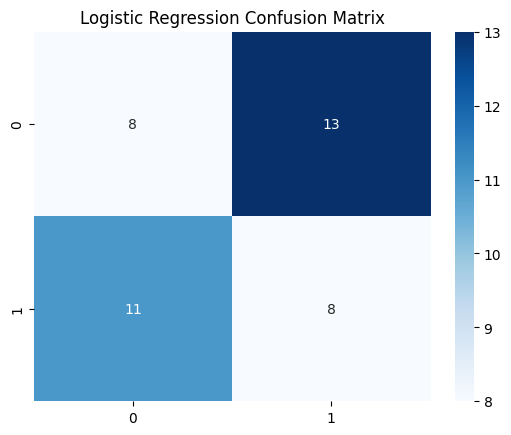

In [ ]:
cm = confusion_matrix(y_test_bin, y_pred_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

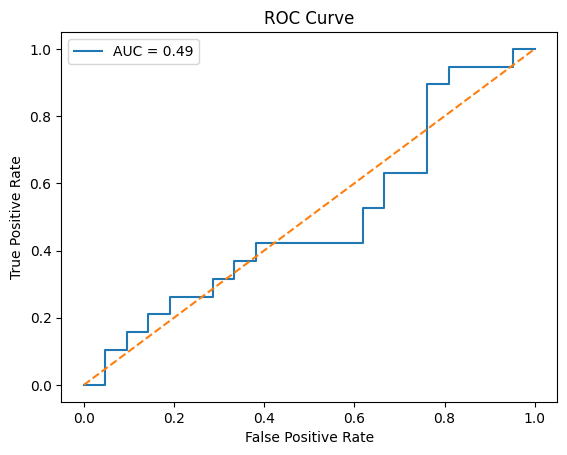

In [ ]:


fpr, tpr, _ = roc_curve(y_test_bin, log_reg.predict_proba(X_test_bin_scaled)[:,1])
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()



## Introduction

This project aims to develop a predictive model for food delivery times. Accurate prediction of delivery times is crucial for optimizing logistics, enhancing customer satisfaction, and improving operational efficiency within the food delivery industry. By leveraging various data points such as weather conditions, traffic, distance, and historical delivery performance, we seek to build a robust model that can provide reliable estimated delivery times.


*   **Improved Customer Experience:** Customers receive realistic expectations, reducing anxiety and increasing satisfaction.
*   **Operational Efficiency:** Delivery companies can better manage their fleet, optimize routes, and reduce wait times for both drivers and customers.
*   **Business Growth:** Reliable service can lead to increased customer loyalty and a competitive advantage in the market.

## Data Overview and Preprocessing



### Dataset Overview

The dataset `Food_Delivery_Time_Prediction.csv` was loaded into a pandas DataFrame named `df`. It contains **200 entries** and **15 columns**.

**Key Features and Data Types:**
- **Numerical (float64):** `Distance`, `Restaurant_Rating`, `Customer_Rating`, `Delivery_Time`, `Order_Cost`, `Tip_Amount`.
- **Numerical (int64):** `Delivery_Person_Experience`.
- **Categorical (object):** `Order_ID`, `Customer_Location`, `Restaurant_Location`, `Weather_Conditions`, `Traffic_Conditions`, `Order_Priority`, `Order_Time`, `Vehicle_Type`.

**Initial Observations:**
- The `Order_ID` column serves as a unique identifier.
- `Customer_Location` and `Restaurant_Location` are string representations of geographical coordinates `(latitude, longitude)`.
- There are no initial missing values visible from `df.info()` output, as all columns have 200 non-null counts.

### Handling Missing Values

Although `df.info()` initially showed no missing values, it's good practice to handle potential missing values that might arise after further processing or in case the dataset changes.

- **Numerical Columns:**  This approach is robust to outliers.
- **Categorical Columns:** This ensures that categorical features remain complete for further analysis.

### Feature Engineering: Haversine Distance Calculation

To accurately calculate the distance between restaurants and customer locations, a `haversine` function was defined. This function takes latitude and longitude coordinates as input and returns the distance in kilometers, using the Earth's radius (R = 6371 km).

**Process:**
1.  **Parsing Location Strings:** A helper function `parse_location_string` was created to extract latitude and longitude from the `Customer_Location` and `Restaurant_Location` columns, which were originally in the format `(latitude, longitude)`. This function converts the string coordinates into numerical `float` values.
2.  **Creating Latitude/Longitude Columns:** The parsed latitude and longitude values were then used to create four new columns in the DataFrame: `Restaurant_lat`, `Restaurant_lon`, `Customer_lat`, and `Customer_lon`.
3.  **Handling Missing Lat/Lon Values:** In case the parsing failed for any reason (resulting in `np.nan`), missing values in these newly created latitude and longitude columns were imputed using the **median** of their respective columns.
4.  **Calculating Distance:** Finally, the `haversine` function was applied using these new latitude and longitude columns to compute the `Distance` between the restaurant and customer, updating the existing 'Distance' column with the more accurate haversine calculation.

### Encoding Categorical Variables

To prepare categorical features for machine learning models, they were transformed into numerical representations using **Label Encoding**. This technique assigns a unique integer to each category in a column.

The following categorical columns were encoded:

- `Weather_Conditions`
- `Traffic_Conditions`
- `Vehicle_Type`
- `Order_Priority`
- `Order_Time`

Each unique value in these columns was mapped to a numerical label, allowing models to process them effectively.

### Outlier Treatment using IQR

Outliers in the `Distance` and `Delivery_Time` columns were identified and treated using the Interquartile Range (IQR) method. This method helps to mitigate the impact of extreme values on model training.

**Process:**
1.  **Define Outlier Thresholds:** For each column, the First Quartile (Q1) and Third Quartile (Q3) were calculated. The IQR was then determined as `Q3 - Q1`.
2.  **Identify Outliers:** Values falling below `Q1 - 1.5 * IQR` or above `Q3 + 1.5 * IQR` were identified as outliers.
3.  **Impute Outliers:** Instead of removing them, the identified outlier values in `Distance` and `Delivery_Time` were replaced with the **median** of their respective columns. This approach preserves data points while reducing the influence of extreme values, which is particularly useful for regression tasks.

## Methodology


1.  **Data Splitting Strategy**: This process was consistently applied to both the features (X) and the target variable (y) to ensure data integrity across the splits.

2.  **Feature Scaling**:  This scaling process is crucial for many machine learning algorithms, including Linear Regression and Logistic Regression, as it ensures that no single feature dominates the learning process due to its scale, leading to better model performance and faster convergence.

3.  **Regression Model (Linear Regression)**: This model aims to establish a linear relationship between the input features and the delivery time, providing a direct numerical prediction.

4.  **Classification Model (Logistic Regression)**: For classification tasks, a binary target variable `y_binary` was introduced. This was created by categorizing `Delivery_Time` into 'Fast' or 'Delayed' based on the median `Delivery_Time` of the original dataset. Specifically, `Delivery_Time` values less than the median were labeled 'Fast' (represented as 1), and those greater than or equal to the median were labeled 'Delayed' (represented as 0). A separate data split (`train_test_split`) with a 80/20 train/test ratio was performed for this binary classification problem, and a `StandardScaler` was applied to scale the features (`X_train_bin`, `X_test_bin`). `LogisticRegression` was then trained on this scaled binary data to predict the probability of a delivery being 'Fast' or 'Delayed'.

### Linear Regression Model Performance on Validation Set

The evaluation metrics for the Linear Regression model on the validation set are as follows:

*   **Mean Absolute Error (MAE):** 26.77
*   **Root Mean Squared Error (RMSE):** 31.64
*   **R-squared (R2):** 0.066

#### Interpretation of Metrics:

*   **Mean Absolute Error (MAE):** The MAE of 26.77 minutes indicates that, on average, our Linear Regression model's predictions for delivery time are off by approximately 26.77 minutes from the actual delivery time. This provides a direct measure of the average magnitude of the errors.

*   **Root Mean Squared Error (RMSE):** The RMSE of 31.64 minutes is also a measure of the average magnitude of the errors, similar to MAE, but it gives relatively high weight to large errors because the errors are squared before they are averaged. This means that larger prediction errors are penalized more heavily. An RMSE of 31.64 suggests that the model's predictions typically deviate by about 31.64 minutes from the actual delivery times, with larger errors having a greater impact on this value compared to MAE.

*   **R-squared (R2):** This implies that many factors influencing delivery time are not adequately captured by the current features in the linear model, or that the linear relationship between the features and delivery time is weak. Therefore, the model has limited predictive power for explaining the variations in delivery time.


### Logistic Regression Evaluation Metrics:

- **Accuracy: 0.40**
  - **Interpretation**: This metric represents the proportion of correctly classified instances (both 'Fast' and 'Delayed' deliveries) out of the total number of instances. An accuracy of 40% is quite low, suggesting that the model is only correctly predicting the delivery time category (fast or delayed) for 40% of the deliveries. This indicates that the model is not performing well overall in distinguishing between fast and delayed deliveries.

- **Precision: 0.38**
  - **Interpretation**: Precision is the ratio of true positive predictions to the total positive predictions (true positives + false positives). In the context of classifying 'Fast' deliveries (assuming 'Fast' is the positive class), a precision of 38% means that when the model predicts a delivery will be 'Fast', it is only correct 38% of the time. A low precision indicates a high number of false positives, meaning many deliveries predicted as 'Fast' are actually 'Delayed'.

- **Recall: 0.42**
  - **Interpretation**: Recall (also known as sensitivity or true positive rate) is the ratio of true positive predictions to the total actual positive instances (true positives + false negatives). If 'Fast' is the positive class, a recall of 42% means the model correctly identifies only 42% of all actual 'Fast' deliveries. A low recall indicates a high number of false negatives, meaning the model is failing to identify many deliveries that are actually 'Fast'.

- **F1-Score: 0.40**
  - **Interpretation**: The F1-Score is the harmonic mean of precision and recall. It provides a single score that balances both precision and recall. An F1-Score of 40% is relatively low, reflecting the poor performance in both precision and recall, suggesting that the model struggles to effectively identify 'Fast' deliveries while also minimizing false positives and false negatives.

### Confusion Matrix:

The confusion matrix provides a detailed breakdown of correct and incorrect classifications. In our case, `y_binary = (y < y.median()).astype(int)` where 1 represents 'Fast' (delivery time less than median) and 0 represents 'Delayed' (delivery time greater than or equal to median).

```
[[ 8 13]
 [11  8]]
```

- **True Negatives (TN): 8**
  - The model correctly predicted 8 deliveries as 'Delayed' (class 0).
- **False Positives (FP): 13**
  - The model incorrectly predicted 13 deliveries as 'Fast' (class 1) when they were actually 'Delayed' (class 0). This contributes to the low precision.
- **False Negatives (FN): 11**
  - The model incorrectly predicted 11 deliveries as 'Delayed' (class 0) when they were actually 'Fast' (class 1). This contributes to the low recall.
- **True Positives (TP): 8**
  - The model correctly predicted 8 deliveries as 'Fast' (class 1).

**Interpretation**: The confusion matrix shows that the model has a significant number of misclassifications (13 False Positives and 11 False Negatives), leading to poor performance. The counts for correct predictions (True Positives and True Negatives) are quite low, further confirming the model's limitations.

### ROC Curve and AUC:

- **ROC Curve**: The Receiver Operating Characteristic (ROC) curve plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at various classification thresholds. It illustrates the trade-off between sensitivity (TPR) and specificity (1-FPR). A curve that bows towards the top-left corner indicates a better performing model.

- **AUC: 0.49**
  - **Interpretation**: The Area Under the Curve (AUC) measures the entire two-dimensional area underneath the ROC curve. It provides an aggregate measure of performance across all possible classification thresholds. An AUC of 0.5 indicates a model that performs no better than random chance. Our AUC of 0.49 is very close to 0.5, which suggests that the Logistic Regression model has very little discriminative power to distinguish between 'Fast' and 'Delayed' deliveries. An ideal model would have an AUC close to 1.0.



### Summary
This project aimed to predict food delivery times using two different machine learning approaches: Linear Regression for continuous time prediction and Logistic Regression for binary classification (fast vs. delayed deliveries).

**Linear Regression Performance:**
The Linear Regression model, designed to predict the exact delivery time, showed limited predictive power. With an MAE of 26.77 minutes, an RMSE of 31.64 minutes, and a very low R2 score of 0.066, the model could only explain about 6.6% of the variance in delivery times. This suggests that a simple linear relationship is not sufficient to capture the complexities influencing delivery duration, or that the current feature set does not contain enough information for accurate linear prediction.

**Logistic Regression Performance:**
The Logistic Regression model, tasked with classifying deliveries as 'Fast' or 'Delayed' based on the median delivery time, also demonstrated poor performance. Its accuracy, precision, recall, and F1-score were all around 0.40, indicating that the model is barely better than random chance. The AUC score of 0.49 further reinforces this, highlighting a significant lack of discriminative power between the two classes. The confusion matrix revealed a high number of false positives and false negatives, suggesting that the model struggles to correctly identify both fast and delayed deliveries.

